# EDA - MST

Quick, step-by-step exploratory analysis to understand data shape, quality, target distribution, correlations, and potential issues before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("\nTrain columns:", list(train.columns))

Train shape: (20886, 47)
Test shape:  (5300, 46)

Train columns: ['record_id', 'district', 'place_name', 'latitude', 'longitude', 'elevation_m', 'distance_to_river_m', 'landcover', 'soil_type', 'water_supply', 'electricity', 'road_quality', 'population_density_per_km2', 'built_up_percent', 'urban_rural', 'rainfall_7d_mm', 'monthly_rainfall_mm', 'drainage_index', 'ndvi', 'ndwi', 'water_presence_flag', 'historical_flood_count', 'infrastructure_score', 'nearest_hospital_km', 'nearest_evac_km', 'flood_risk_score', 'flood_occurrence_current_event', 'inundation_area_sqm', 'is_good_to_live', 'reason_not_good_to_live', 'is_synthetic', 'generation_date', 'distance_to_river_m_log1p', 'population_density_per_km2_log1p', 'rainfall_7d_mm_log1p', 'monthly_rainfall_mm_log1p', 'nearest_hospital_km_log1p', 'nearest_evac_km_log1p', 'elevation_m_yeojohnson', 'drainage_index_yeojohnson', 'ndvi_qmap', 'ndwi_qmap', 'built_up_percent_qmap', 'seasonal_index', 'terrain_roughness_index', 'socioeconomic_status_i

In [2]:
train.info()
train.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20886 entries, 0 to 20885
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         20886 non-null  object 
 1   district                          20070 non-null  object 
 2   place_name                        20886 non-null  object 
 3   latitude                          20041 non-null  float64
 4   longitude                         20046 non-null  float64
 5   elevation_m                       20095 non-null  float64
 6   distance_to_river_m               19337 non-null  float64
 7   landcover                         20077 non-null  object 
 8   soil_type                         20073 non-null  object 
 9   water_supply                      20098 non-null  object 
 10  electricity                       19282 non-null  object 
 11  road_quality                      19893 non-null  object 
 12  popu

,count,mean,std,min,25%,50%,75%,max
latitude,20041.0,7.916343,1.170395,5.900090,6.902917,7.922158,8.924426,9.949978
longitude,20046.0,80.767153,0.647346,79.650121,80.209477,80.758126,81.326080,81.899993
elevation_m,20095.0,186.090965,321.663187,-79.564149,31.000000,67.000000,123.000000,2148.000000
distance_to_river_m,19337.0,2004.573658,2021.915106,-485.397750,569.700000,1384.600000,2779.500000,16802.000000
population_density_per_km2,20062.0,658.776452,647.966642,10.000000,287.000000,520.000000,798.000000,6642.296345
built_up_percent,20085.0,25.667859,19.936560,1.000000,9.900000,23.300000,37.500000,178.263721
rainfall_7d_mm,20066.0,84.761301,79.509146,-49.199358,32.500000,69.300000,116.800000,914.823318
monthly_rainfall_mm,20075.0,223.786686,179.481637,-79.170571,104.000000,200.200000,305.800000,2032.274155
drainage_index,19571.0,0.505874,0.231942,0.003000,0.333000,0.504000,0.677000,1.779877
ndvi,19625.0,0.174827,0.281910,-0.792000,-0.018000,0.169000,0.358000,1.595039


In [3]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

electricity                         1604
distance_to_river_m                 1549
distance_to_river_m_log1p           1549
ndwi                                1341
ndwi_qmap                           1341
drainage_index_yeojohnson           1315
drainage_index                      1315
ndvi                                1261
ndvi_qmap                           1261
nearest_hospital_km_log1p           1023
nearest_hospital_km                 1023
road_quality                         993
infrastructure_score                 971
latitude                             845
longitude                            840
population_density_per_km2_log1p     824
population_density_per_km2           824
rainfall_7d_mm                       820
rainfall_7d_mm_log1p                 820
district                             816
soil_type                            813
monthly_rainfall_mm                  811
monthly_rainfall_mm_log1p            811
landcover                            809
nearest_evac_km_

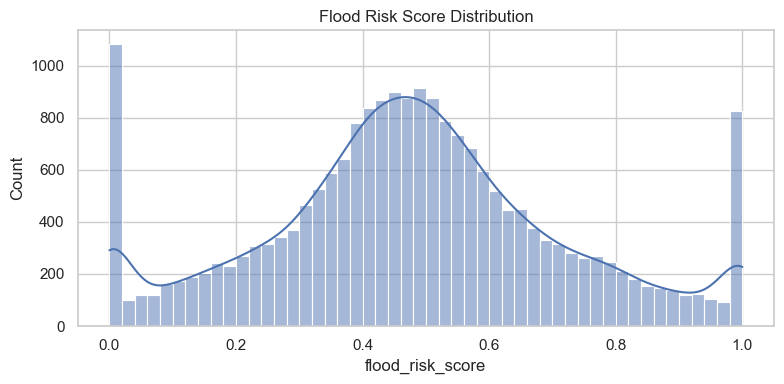

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(train["flood_risk_score"], bins=50, kde=True)
plt.title("Flood Risk Score Distribution")
plt.tight_layout()
plt.show()

flood_risk_score                    1.000000
distance_to_river_m_log1p           0.081028
distance_to_river_m                 0.074081
infrastructure_score                0.037625
longitude                           0.011737
elevation_m                         0.011512
socioeconomic_status_index          0.006323
elevation_m_yeojohnson              0.005708
seasonal_index                      0.003636
latitude                            0.003208
nearest_hospital_km_log1p           0.002618
nearest_hospital_km                 0.001584
ndvi_qmap                          -0.001665
ndvi                               -0.002163
nearest_evac_km                    -0.007768
nearest_evac_km_log1p              -0.008228
drainage_index_yeojohnson          -0.015685
drainage_index                     -0.016040
built_up_percent_qmap              -0.017292
terrain_roughness_index            -0.020773
built_up_percent                   -0.021014
monthly_rainfall_mm                -0.021766
ndwi      

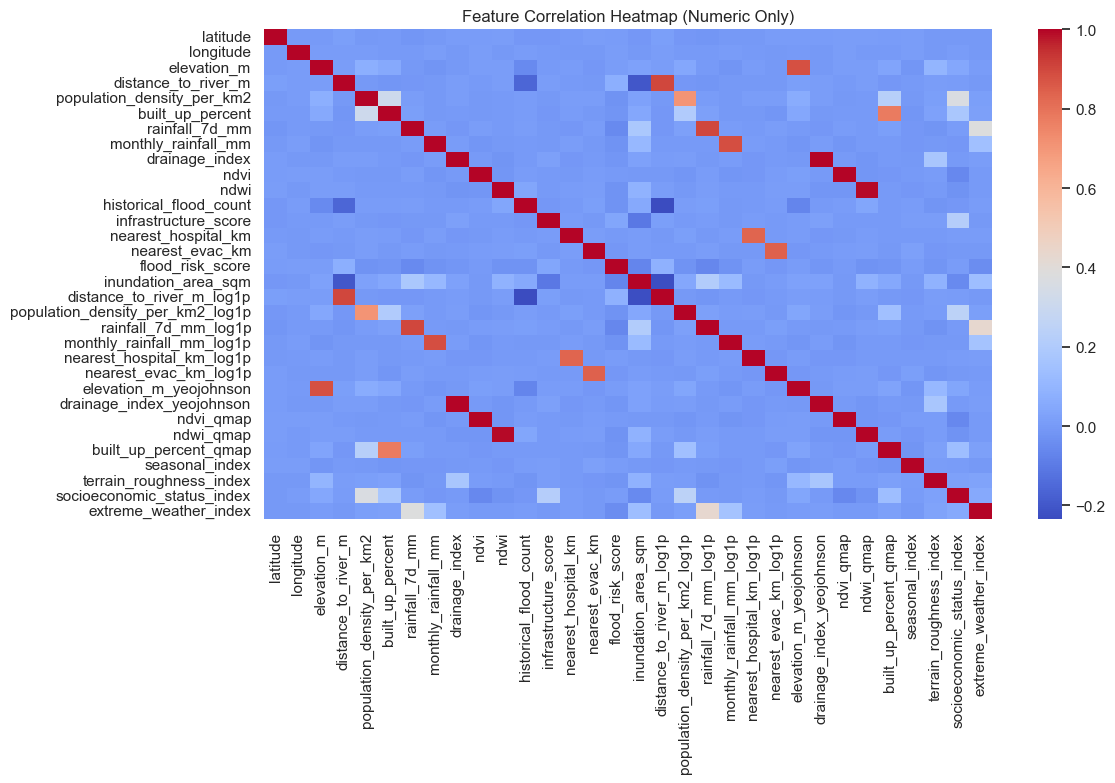

In [5]:
numeric_train = train.select_dtypes(include=["number"]).copy()

if "flood_risk_score" in numeric_train.columns:
    corr = numeric_train.corr()["flood_risk_score"].sort_values(ascending=False)
    print(corr)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_train.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap (Numeric Only)")
plt.tight_layout()
plt.show()

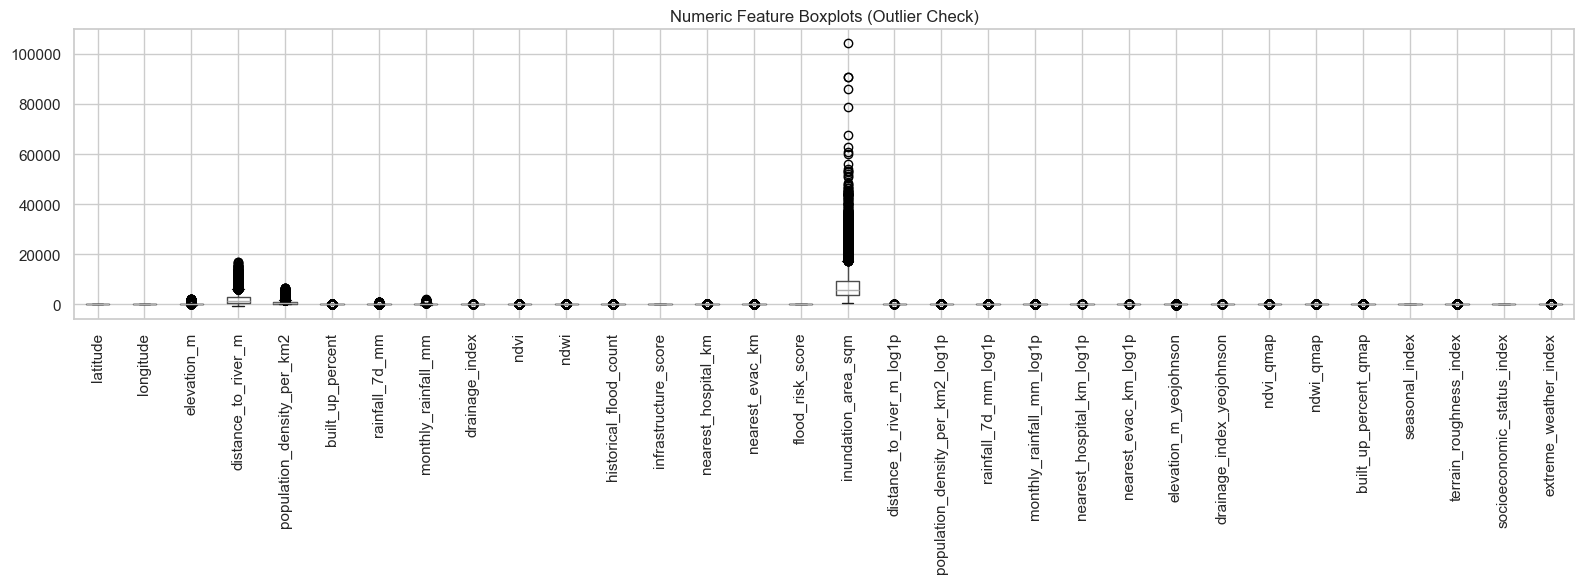

In [6]:
plt.figure(figsize=(16, 6))
train.select_dtypes(include=["number"]).boxplot()
plt.xticks(rotation=90)
plt.title("Numeric Feature Boxplots (Outlier Check)")
plt.tight_layout()
plt.show()

In [7]:
cat_cols = train.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", cat_cols)

for col in cat_cols:
    print(f"\n{col}: {train[col].nunique()} unique values")
    print(train[col].value_counts().head())

Categorical columns: ['record_id', 'district', 'place_name', 'landcover', 'soil_type', 'water_supply', 'electricity', 'road_quality', 'urban_rural', 'water_presence_flag', 'flood_occurrence_current_event', 'is_good_to_live', 'reason_not_good_to_live', 'is_synthetic', 'generation_date']

record_id: 19700 unique values
record_id
F108826    2
F100792    2
F124958    2
F107991    2
F103905    2
Name: count, dtype: int64

district: 25 unique values
district
Kandy         881
Batticaloa    838
Colombo       827
Matale        825
Kurunegala    821
Name: count, dtype: int64

place_name: 792 unique values
place_name
Welipola West          45
Mahawatta              44
Nayamedura East        42
Nayawatta West         42
Ihalamedura Central    42
Name: count, dtype: int64

landcover: 7 unique values
landcover
Agriculture    5454
Urban          3700
Forest         3086
Plantation     2499
Scrub          2412
Name: count, dtype: int64

soil_type: 5 unique values
soil_type
Silty    4134
Peaty    4032

## EDA Notes (fill in after running)

| Question | Answer |
|---|---|
| How many rows in train/test? | 20886 |
| Any missing values? Which columns? | ? |
| Is target skewed or uniform? | ? |
| Which features correlate most with target? | ? |
| Any obvious outliers? | ? |
| How many categorical vs numerical columns? | ? |

Next flow: EDA → Feature Engineering → Baseline Model → Tuning → Ensemble

In [8]:
train.groupby("is_good_to_live")["flood_risk_score"].mean()

is_good_to_live
No     0.475765
Yes    0.505799
Name: flood_risk_score, dtype: float64

In [9]:
# See if missing rows overlap
mask = train['district'].isnull()
print(train[mask][['electricity', 'ndwi', 'soil_type', 'elevation_m']].isnull().sum())

electricity    399
ndwi           407
soil_type      400
elevation_m    414
dtype: int64


In [10]:
missing_per_row = train.isnull().sum(axis=1)
print(missing_per_row.value_counts().head(10))

0     14644
1      1807
2      1085
4       991
3       667
5       395
6       349
25       87
22       85
26       84
Name: count, dtype: int64


In [11]:
cat_cols = ['district', 'landcover', 'soil_type', 
            'urban_rural', 'water_supply', 'road_quality',
            'flood_occurrence_current_event', 'is_good_to_live']

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(train.groupby(col)['flood_risk_score'].mean().sort_values(ascending=False))


--- district ---
district
Vavuniya        0.538169
Monaragala      0.533144
Mullaitivu      0.514518
Badulla         0.513043
Kurunegala      0.504286
Kandy           0.501458
Puttalam        0.500797
Matara          0.495810
Kegalle         0.490781
Kalutara        0.490570
Anuradhapura    0.479868
Gampaha         0.478706
Batticaloa      0.475648
Ampara          0.472565
Mannar          0.466662
Ratnapura       0.466135
Galle           0.465726
Nuwara Eliya    0.461781
Hambantota      0.458248
Matale          0.455008
Jaffna          0.453362
Polonnaruwa     0.453250
Kilinochchi     0.429653
Trincomalee     0.412421
Colombo         0.409929
Name: flood_risk_score, dtype: float64

--- landcover ---
landcover
Urban          0.485069
Forest         0.479564
Agriculture    0.478367
Plantation     0.474698
Scrub          0.474587
Bare Soil      0.472775
Wetland        0.469581
Name: flood_risk_score, dtype: float64

--- soil_type ---
soil_type
Clay     0.484905
Sandy    0.478416
Peaty   

In [12]:
# Look at the extreme risk rows
high_risk = train[train['flood_risk_score'] >= 0.95]
low_risk  = train[train['flood_risk_score'] <= 0.05]

print("HIGH RISK rows:", len(high_risk))
print("LOW RISK rows: ", len(low_risk))

# What do they have in common?
print(high_risk[['district','landcover','soil_type','flood_occurrence_current_event']].value_counts().head())

HIGH RISK rows: 965
LOW RISK rows:  1231
district      landcover    soil_type  flood_occurrence_current_event
Vavuniya      Agriculture  Sandy      Yes                               4
Mullaitivu    Urban        Loamy      Yes                               4
Anuradhapura  Urban        Sandy      Yes                               4
Galle         Agriculture  Clay       No                                4
Ampara        Agriculture  Silty      No                                4
Name: count, dtype: int64


In [13]:
print(train.groupby('flood_occurrence_current_event')['flood_risk_score'].describe())

                                  count      mean       std  min     25%  \
flood_occurrence_current_event                                             
No                               9847.0  0.494688  0.240154  0.0  0.3553   
Yes                             11039.0  0.463194  0.236558  0.0  0.3267   

                                   50%      75%  max  
flood_occurrence_current_event                        
No                              0.4917  0.63285  1.0  
Yes                             0.4593  0.59575  1.0  


## Additional EDA Checks

In [ ]:
# STEP 1: Check if missing rows are same batch
missing_per_row = train.isnull().sum(axis=1)
print("Missing value distribution per row:")
print(missing_per_row.value_counts().sort_index().head(15))

missing_per_row.hist(bins=30)
plt.title("How many columns are missing per row?")
plt.xlabel("Number of missing columns")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.show()

heavy_missing = train[missing_per_row > 10]
cols_to_check = [
    "district",
    "electricity",
    "ndwi",
    "soil_type",
    "elevation_m",
]
cols_to_check = [col for col in cols_to_check if col in train.columns]
print(f"\nRows missing more than 10 columns: {len(heavy_missing)}")
print(heavy_missing[cols_to_check].isnull().sum())

In [ ]:
# STEP 2: Categorical columns vs flood_risk_score
cat_cols = [
    "district",
    "landcover",
    "soil_type",
    "urban_rural",
    "water_supply",
    "road_quality",
    "flood_occurrence_current_event",
    "is_good_to_live",
]
cat_cols = [col for col in cat_cols if col in train.columns]

for col in cat_cols:
    print(f"\n{'='*40}")
    print(f"  {col}")
    print(f"{'='*40}")
    print(
        train.groupby(col)["flood_risk_score"]
        .mean()
        .sort_values(ascending=False)
        .round(4)
    )

In [ ]:
# STEP 3: Investigate 0.0 and 1.0 spike rows
high_risk = train[train["flood_risk_score"] >= 0.95]
low_risk = train[train["flood_risk_score"] <= 0.05]

print(f"High risk rows (>= 0.95): {len(high_risk)}")
print(f"Low risk rows (<= 0.05):  {len(low_risk)}")

cols_to_review = [
    "district",
    "landcover",
    "soil_type",
    "flood_occurrence_current_event",
]
cols_to_review = [col for col in cols_to_review if col in train.columns]

print("\nHigh risk common patterns:")
print(high_risk[cols_to_review].value_counts().head())

print("\nLow risk common patterns:")
print(low_risk[cols_to_review].value_counts().head())